# GRaFT Python analysis workflow

This notebook loads GRaFT CSV exports and generates the non-map statistical plots used for grain-resolved fabric and texture interpretation.

The MATLAB/MTEX GRaFT workflow exports:
- `*_grains.csv`
- `*_contacts.csv`
- `*_pixels.csv`
- `AllSamples_TextureStats.csv`

This notebook uses:
- grain-scale properties from `*_grains.csv`
- nearest-neighbour pair data from `*_contacts.csv`
- pixel-scale internal misorientation metrics from `*_pixels.csv`, if required

<h4>Imports, paths and style</h4>

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

base_dir = Path("GRaFT")
csv_dir = base_dir / "exports"
py_out = base_dir / "python_plots"
py_out.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

def savefig(name: str):
    plt.tight_layout()
    plt.savefig(py_out / name, dpi=300, bbox_inches="tight")
    plt.show()

print("CSV directory:", csv_dir.resolve())
print("Plot output directory:", py_out.resolve())

CSV directory: C:\Users\d67199rs\OneDrive - The University of Manchester\Project 2 - EBSD\MATLAB\GRaFT\exports
Plot output directory: C:\Users\d67199rs\OneDrive - The University of Manchester\Project 2 - EBSD\MATLAB\GRaFT\python_plots


<h4>Load GRaFT exports</h4>

In [2]:
grain_files = sorted(csv_dir.glob("*_grains.csv"))
contact_files = sorted(csv_dir.glob("*_contacts.csv"))
pixel_files = sorted(csv_dir.glob("*_pixels.csv"))
summary_file = csv_dir / "AllSamples_TextureStats.csv"

if len(grain_files) == 0:
    raise FileNotFoundError(f"No *_grains.csv files found in {csv_dir}")

grains = pd.concat(
    [pd.read_csv(f, dtype={"Sample": str, "Phase": str}) for f in grain_files],
    ignore_index=True
)

if len(contact_files) > 0:
    contacts = pd.concat(
        [pd.read_csv(f, dtype={"Sample": str, "Phase": str}) for f in contact_files],
        ignore_index=True
    )
else:
    contacts = pd.DataFrame()

if len(pixel_files) > 0:
    pixels = pd.concat(
        [pd.read_csv(f, dtype={"Sample": str, "Phase": str}) for f in pixel_files],
        ignore_index=True
    )
else:
    pixels = pd.DataFrame()

texture_stats = pd.read_csv(summary_file) if summary_file.exists() else pd.DataFrame()

print("grain files:", len(grain_files), " rows:", len(grains))
print("contact files:", len(contact_files), " rows:", len(contacts))
print("pixel files:", len(pixel_files), " rows:", len(pixels))
print("texture stats rows:", len(texture_stats))

grain files: 9  rows: 2253
contact files: 4  rows: 3069
pixel files: 4  rows: 34110943
texture stats rows: 9


<h4>Basic checks and sample ordering</h4>

In [3]:
required_grain_cols = [
    "Sample", "Phase", "GrainID", "Area", "ECD", "AspectRatio",
    "LongAxisAngle", "GOS", "aAxisAngle", "bAxisAngle", "cAxisAngle"
]

missing_grain_cols = [c for c in required_grain_cols if c not in grains.columns]
if missing_grain_cols:
    raise ValueError(f"Missing grain columns: {missing_grain_cols}")

required_contact_cols = [
    "Sample", "Phase", "GrainID_1", "GrainID_2",
    "MisorientationDeg", "DeltaLongAxisDeg",
    "DeltaAAxisDeg", "DeltaBAxisDeg", "DeltaCAxisDeg"
]

if not contacts.empty:
    missing_contact_cols = [c for c in required_contact_cols if c not in contacts.columns]
    if missing_contact_cols:
        raise ValueError(f"Missing contact columns: {missing_contact_cols}")

samples = sorted(grains["Sample"].astype(str).unique())
samples = samples[:4]

print("Samples used:", samples)

display(grains.groupby(["Sample", "Phase"]).size().rename("NGrains").reset_index())

if not contacts.empty:
    display(contacts.groupby(["Sample", "Phase"]).size().rename("NContacts").reset_index())

Samples used: ['01a2', '01a6', '024', '4N3C']


,Sample,Phase,NGrains
0,01a2,Anorthite,479
1,01a2,Forsterite,5
2,01a6,Anorthite,448
3,01a6,Diopside,31
4,01a6,Forsterite,8
5,024,Anorthite,507
6,024,Forsterite,56
7,4N3C,Anorthite,678
8,4N3C,Forsterite,41


,Sample,Phase,NContacts
0,01a2,Anorthite,830
1,01a6,Anorthite,674
2,024,Anorthite,592
3,4N3C,Anorthite,973


## Figure 1: Aspect ratio distributions

This figure summarises Anorthite grain-shape distributions using aspect ratio histograms. Distributions are plotted as densities to allow comparison between samples with different grain counts.

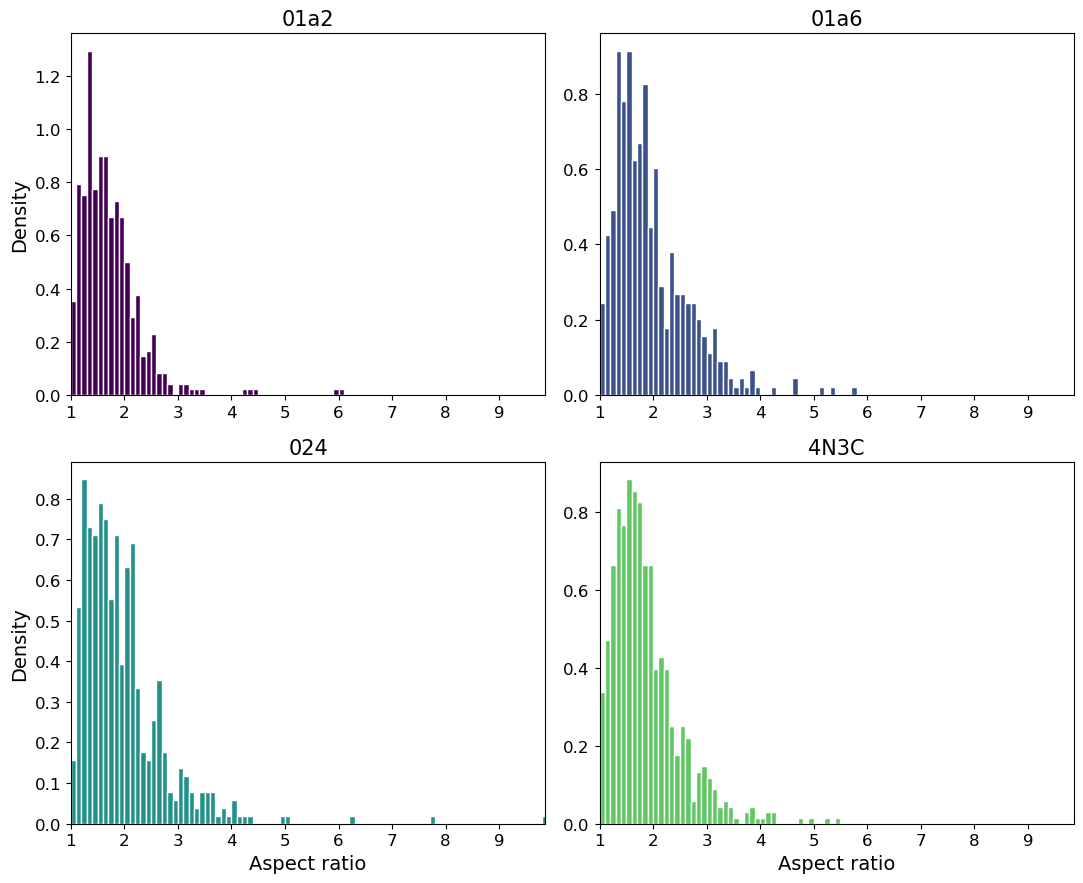

In [4]:
an_grains = grains.loc[grains["Phase"].str.lower() == "anorthite"].copy()

if an_grains.empty:
    raise ValueError("No Anorthite grains found.")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(11, 9))
axes = axes.flatten()

cmap = plt.get_cmap("viridis", len(samples) + 1)

global_max = 0
for sample in samples:
    data = an_grains.loc[an_grains["Sample"].astype(str) == sample, "AspectRatio"].dropna()
    if not data.empty:
        global_max = max(global_max, data.max())

custom_bins = np.arange(1, global_max + 0.2, 0.1)

for i, sample in enumerate(samples):
    ax = axes[i]
    color = cmap(i)
    data = an_grains.loc[an_grains["Sample"].astype(str) == sample, "AspectRatio"].dropna()

    if len(data) < 5:
        ax.set_visible(False)
        continue

    ax.hist(data, bins=custom_bins, edgecolor="white", color=color, density=True)
    ax.set_title(sample)
    ax.set_xlim(1, global_max)

    if i >= 2:
        ax.set_xlabel("Aspect ratio")
    if i % 2 == 0:
        ax.set_ylabel("Density")

for j in range(len(samples), len(axes)):
    axes[j].set_visible(False)

savefig("Results_AR_Panel.png")

## Figure 2: Shape preferred orientation at sample and neighbour scales

This figure compares sample-scale grain long-axis orientations with nearest-neighbour long-axis angular differences.

The left column shows the distribution of grain long-axis orientations over 0--180°. The right column shows pairwise nearest-neighbour long-axis differences over 0--90°.

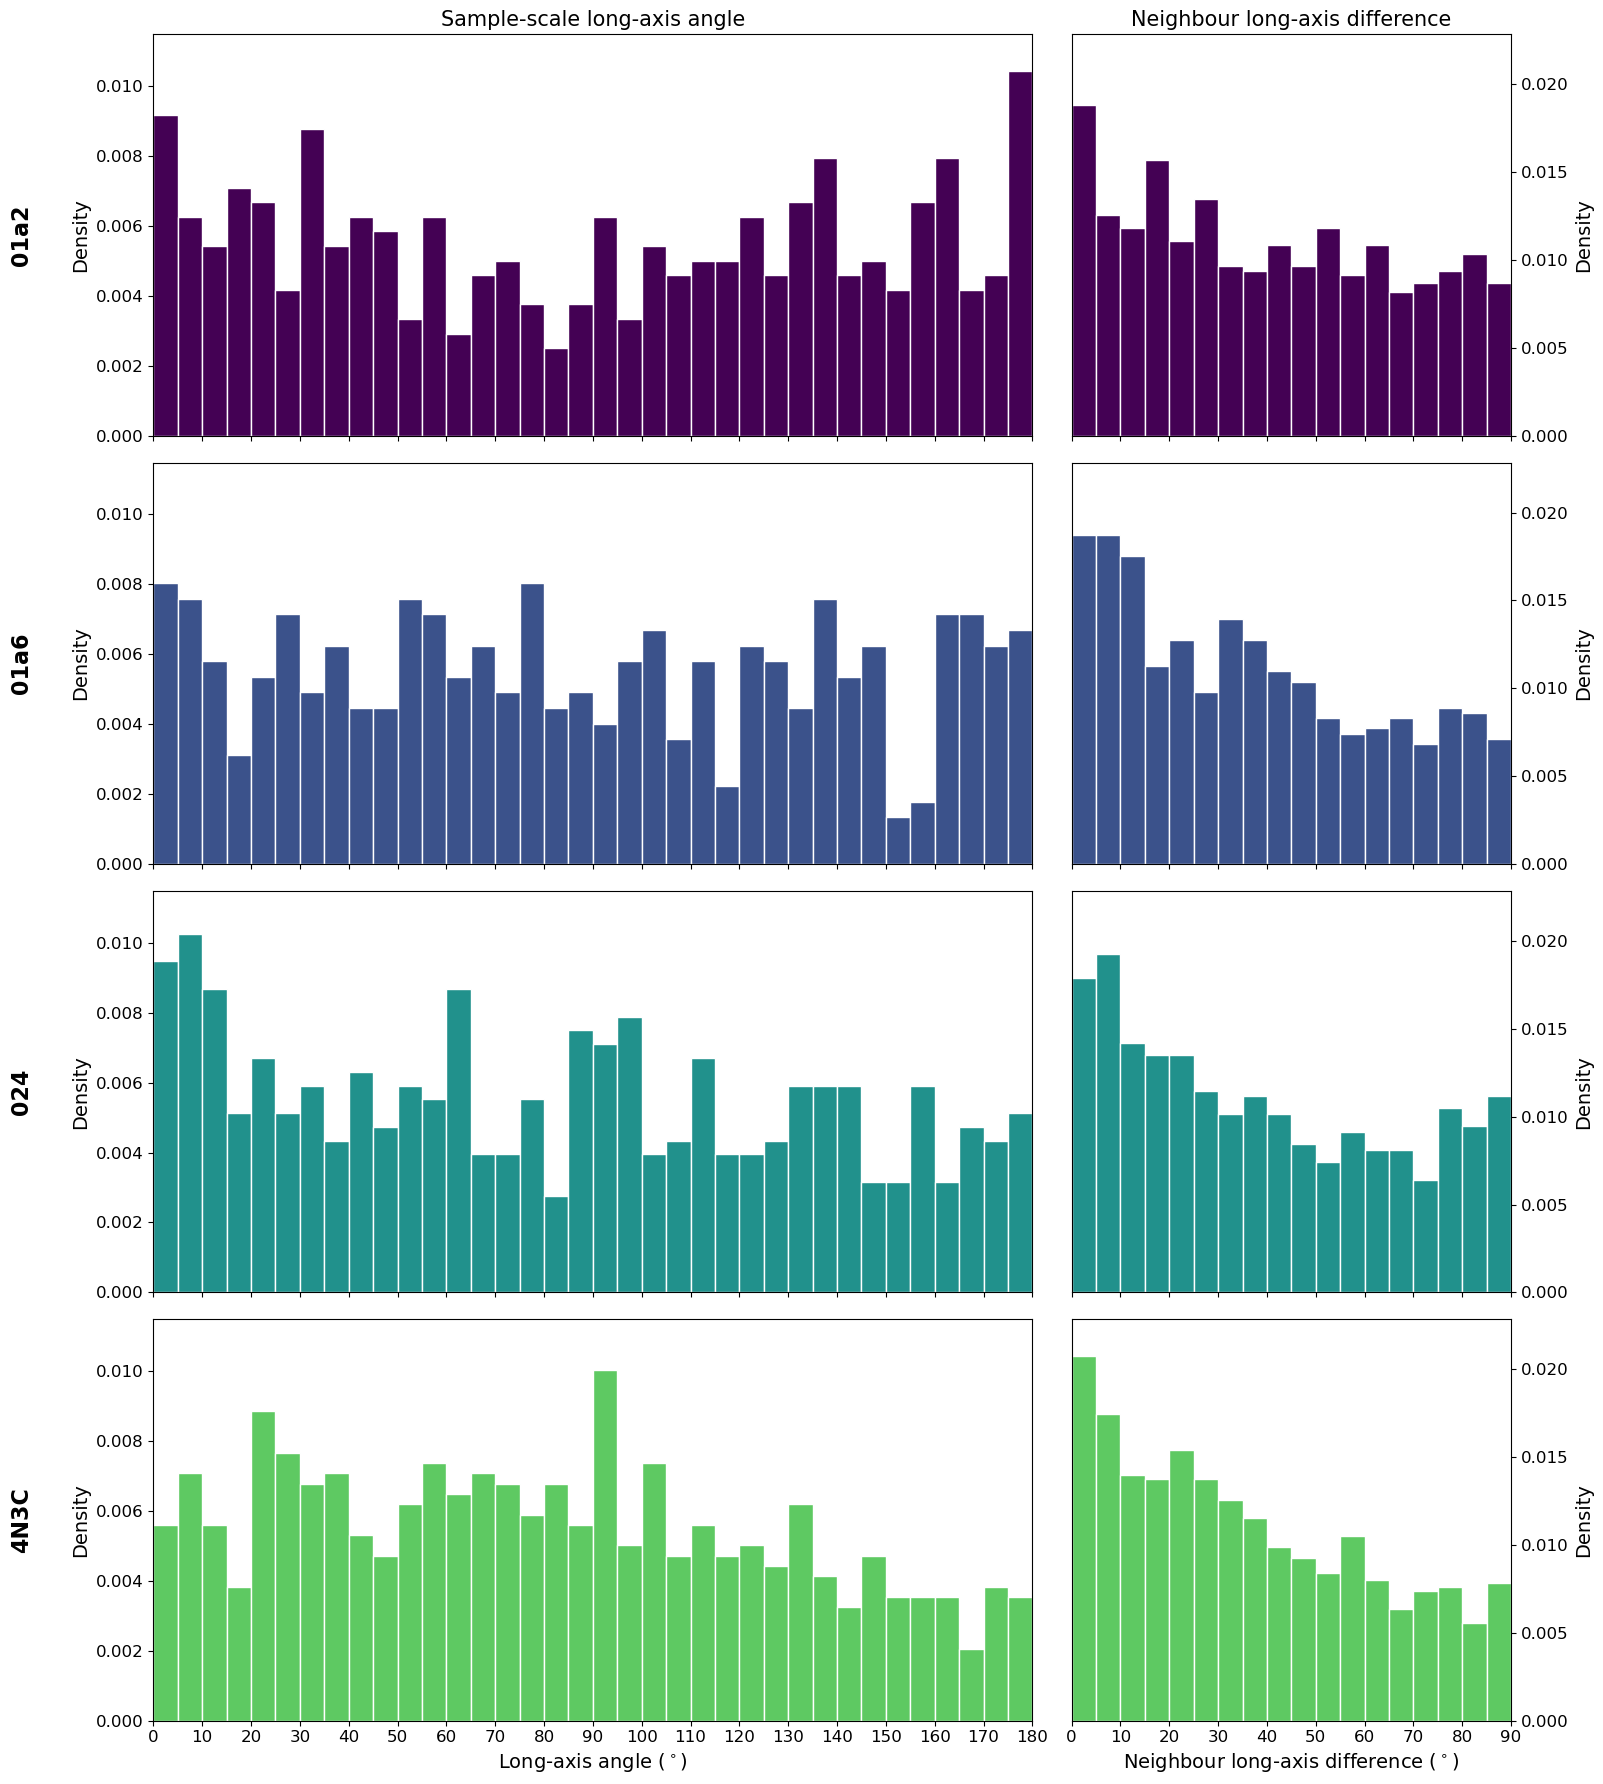

In [5]:
if contacts.empty:
    raise ValueError("No contact table loaded. Nearest-neighbour SPO analysis requires *_contacts.csv files.")

fig, axes = plt.subplots(
    nrows=len(samples),
    ncols=2,
    figsize=(16, 4.5 * len(samples)),
    sharex="col",
    sharey=False,
    gridspec_kw={"width_ratios": [2, 1]}
)

if len(samples) == 1:
    axes = np.expand_dims(axes, axis=0)

cmap = plt.get_cmap("viridis", len(samples) + 1)

bins_sample = np.arange(0, 185, 5)
bins_neighbour = np.arange(0, 95, 5)

y_max_sample = 0
y_max_neighbour = 0

for sample in samples:
    data_sample = an_grains.loc[
        an_grains["Sample"].astype(str) == sample,
        "LongAxisAngle"
    ].dropna()

    data_neighbour = contacts.loc[
        contacts["Sample"].astype(str) == sample,
        "DeltaLongAxisDeg"
    ].dropna()

    if not data_sample.empty:
        counts, _ = np.histogram(data_sample, bins=bins_sample, density=True)
        y_max_sample = max(y_max_sample, np.max(counts))

    if not data_neighbour.empty:
        counts, _ = np.histogram(data_neighbour, bins=bins_neighbour, density=True)
        y_max_neighbour = max(y_max_neighbour, np.max(counts))

for i, sample in enumerate(samples):
    color = cmap(i)

    ax0 = axes[i, 0]
    data_sample = an_grains.loc[
        an_grains["Sample"].astype(str) == sample,
        "LongAxisAngle"
    ].dropna()

    ax0.hist(data_sample, bins=bins_sample, density=True, edgecolor="white", color=color)
    ax0.set_xlim(0, 180)
    ax0.set_xticks(np.arange(0, 181, 10))
    ax0.set_ylim(0, y_max_sample * 1.1)
    ax0.set_ylabel("Density")

    ax0.text(
        -0.15, 0.5, sample,
        transform=ax0.transAxes,
        va="center",
        ha="center",
        fontweight="bold",
        fontsize=16,
        rotation=90
    )

    if i == 0:
        ax0.set_title("Sample-scale long-axis angle")
    if i == len(samples) - 1:
        ax0.set_xlabel("Long-axis angle ($^\\circ$)")

    ax1 = axes[i, 1]
    data_neighbour = contacts.loc[
        contacts["Sample"].astype(str) == sample,
        "DeltaLongAxisDeg"
    ].dropna()

    ax1.hist(data_neighbour, bins=bins_neighbour, density=True, edgecolor="white", color=color)
    ax1.set_xlim(0, 90)
    ax1.set_xticks(np.arange(0, 91, 10))
    ax1.set_ylim(0, y_max_neighbour * 1.1)
    ax1.yaxis.tick_right()
    ax1.yaxis.set_label_position("right")
    ax1.set_ylabel("Density")

    if i == 0:
        ax1.set_title("Neighbour long-axis difference")
    if i == len(samples) - 1:
        ax1.set_xlabel("Neighbour long-axis difference ($^\\circ$)")

savefig("SPO_long_axis_histograms.png")

## Figure 3: Crystallographic axis-angle distributions

This figure shows sample-scale distributions of the crystallographic \(a\)-, \(b\)- and \(c\)-axis orientations for Anorthite grains. Angles are reported in the sample reference frame over 0--180°.

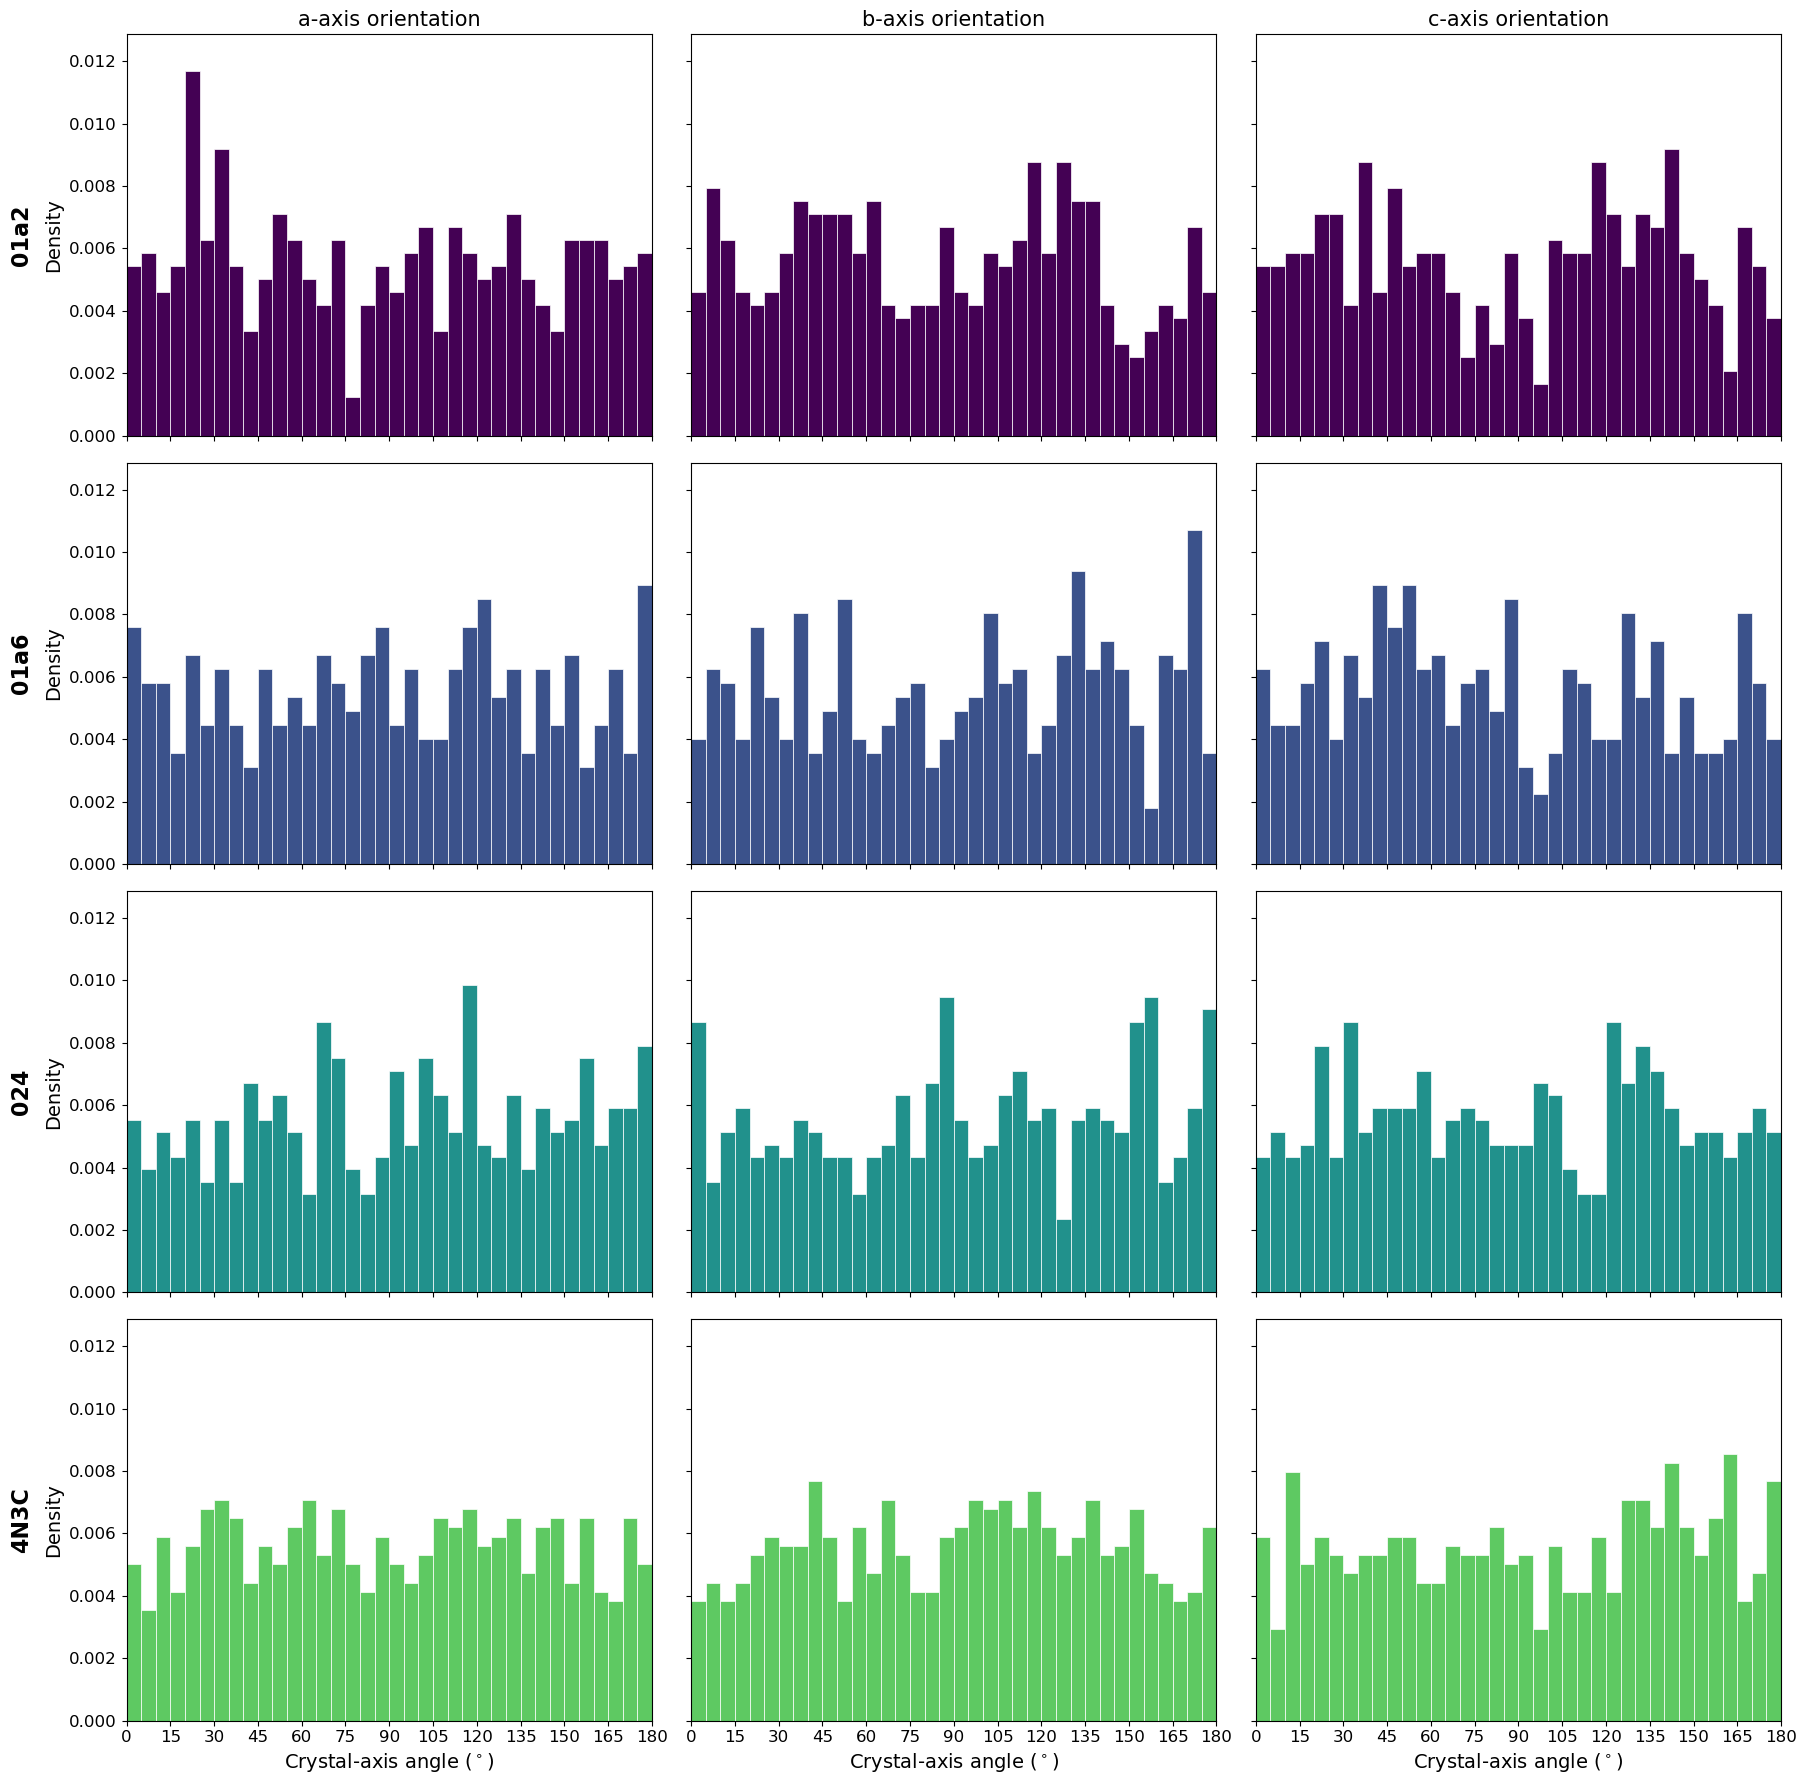

In [6]:
axes_cols = ["aAxisAngle", "bAxisAngle", "cAxisAngle"]
axis_labels = ["a-axis", "b-axis", "c-axis"]

fig, axes = plt.subplots(
    nrows=len(samples),
    ncols=3,
    figsize=(18, 4.5 * len(samples)),
    sharex=True,
    sharey=True
)

if len(samples) == 1:
    axes = axes.reshape(1, -1)

cmap = plt.get_cmap("viridis", len(samples) + 1)
bins = np.arange(0, 185, 5)

y_max = 0
for sample in samples:
    data_sample = an_grains.loc[an_grains["Sample"].astype(str) == sample]
    for col in axes_cols:
        data = data_sample[col].dropna()
        if not data.empty:
            counts, _ = np.histogram(data, bins=bins, density=True)
            y_max = max(y_max, np.max(counts))

for i, sample in enumerate(samples):
    color = cmap(i)
    data_sample = an_grains.loc[an_grains["Sample"].astype(str) == sample]

    for j, (col, label) in enumerate(zip(axes_cols, axis_labels)):
        ax = axes[i, j]
        data = data_sample[col].dropna()

        if data.empty:
            ax.set_visible(False)
            continue

        ax.hist(data, bins=bins, density=True, color=color, edgecolor="white", linewidth=0.5)
        ax.set_xlim(0, 180)
        ax.set_ylim(0, y_max * 1.1)
        ax.set_xticks(np.arange(0, 181, 15))

        if i == 0:
            ax.set_title(f"{label} orientation")

        if j == 0:
            ax.set_ylabel("Density")
            ax.text(
                -0.2, 0.5, sample,
                transform=ax.transAxes,
                va="center",
                ha="center",
                fontweight="bold",
                fontsize=16,
                rotation=90
            )

        if i == len(samples) - 1:
            ax.set_xlabel("Crystal-axis angle ($^\\circ$)")

savefig("CPO_crystal_axis_histograms.png")

## Figure 4: Nearest-neighbour crystallographic axis differences

This figure shows pairwise nearest-neighbour angular differences for the Anorthite \(a\)-, \(b\)- and \(c\)-axes. Differences are reduced to 0--90°.

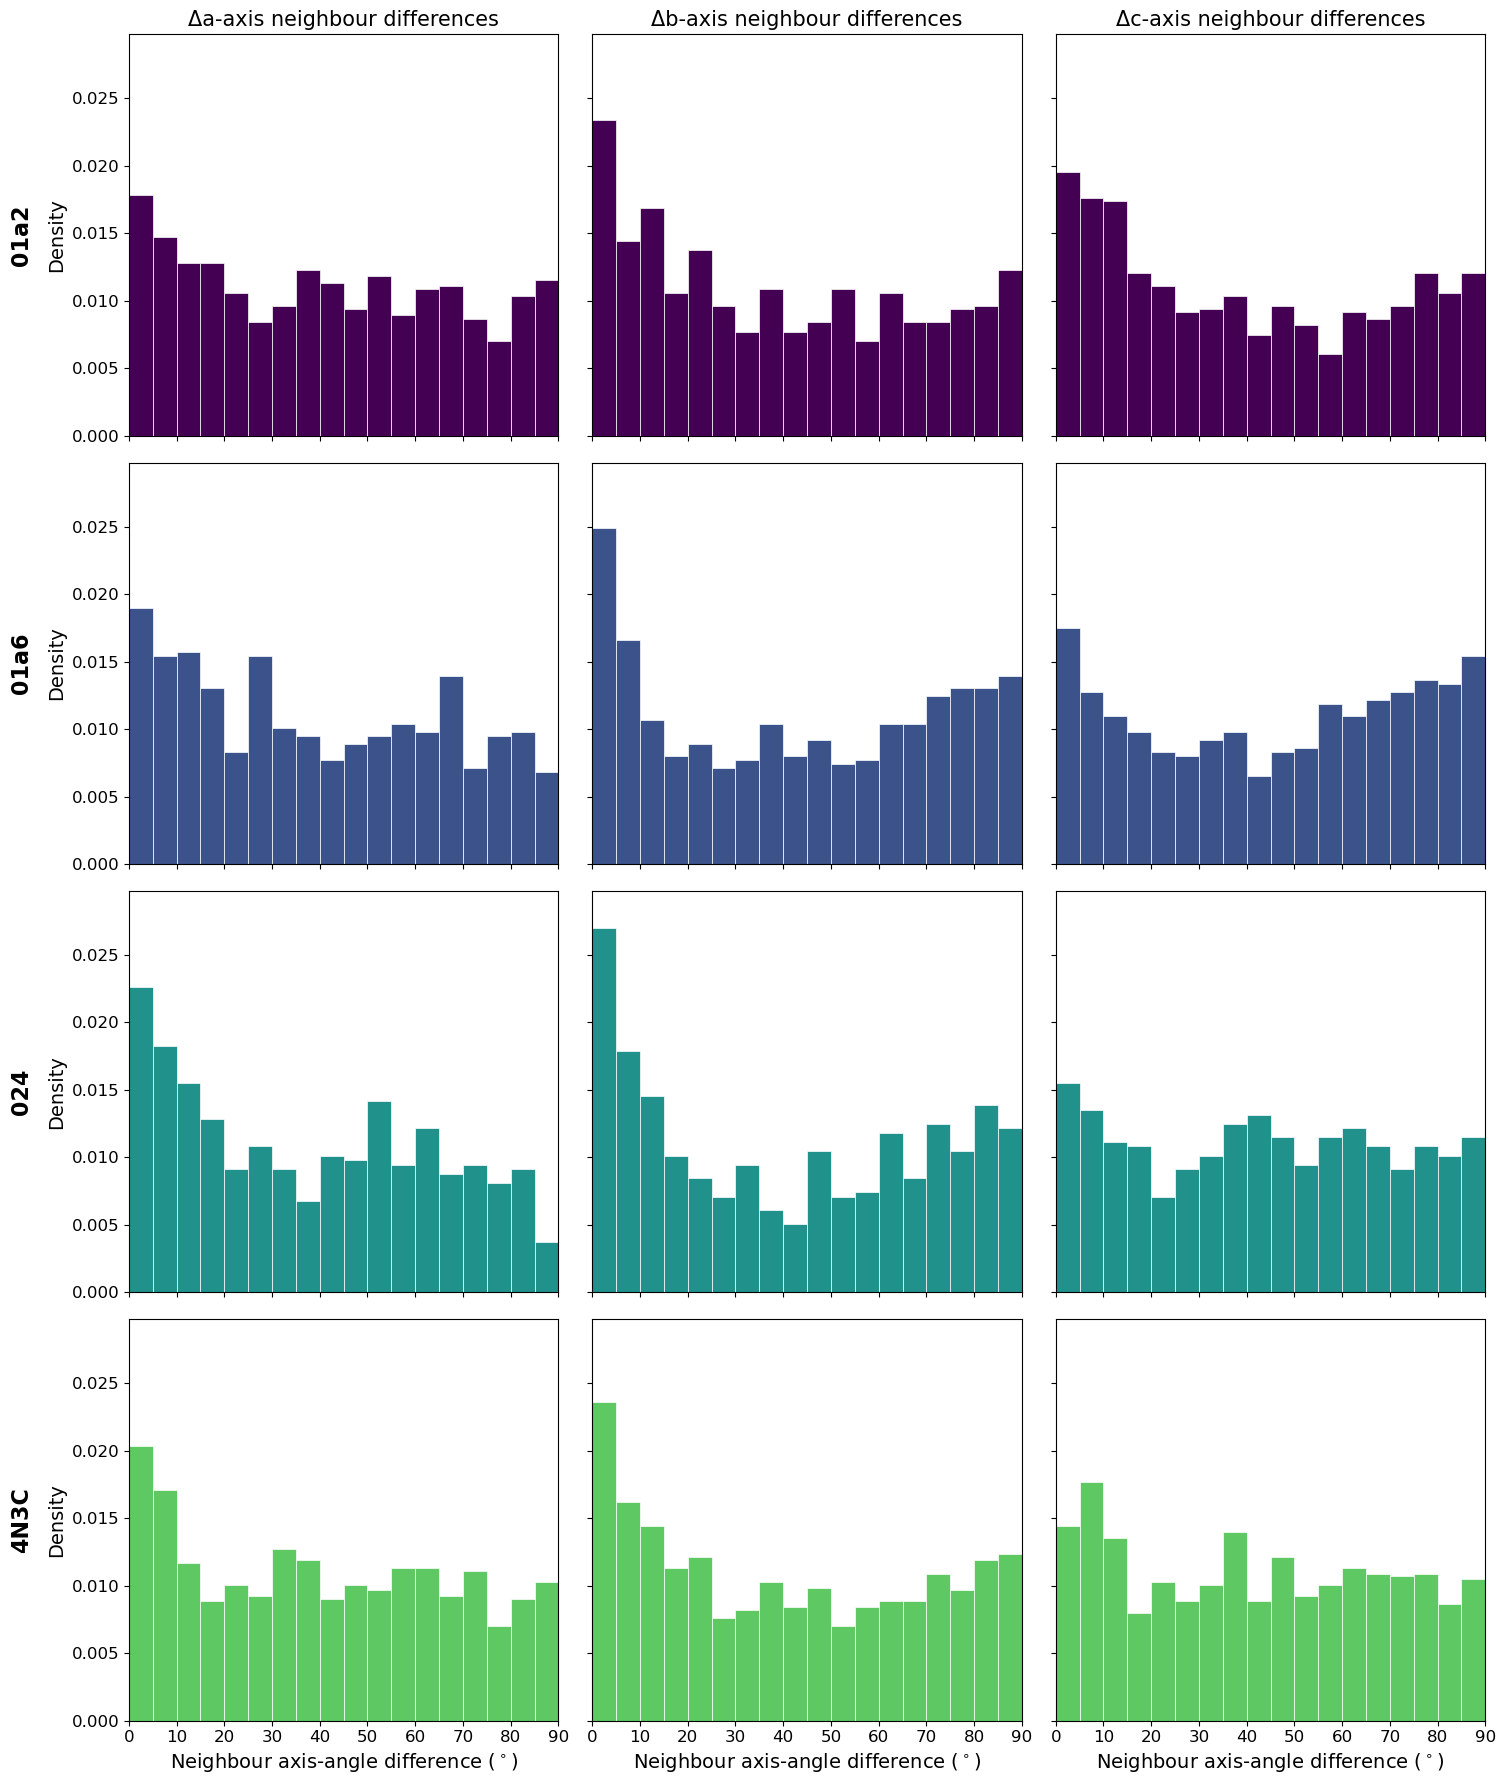

In [7]:
axis_cols = ["DeltaAAxisDeg", "DeltaBAxisDeg", "DeltaCAxisDeg"]
axis_labels = ["Δa-axis", "Δb-axis", "Δc-axis"]

fig, axes = plt.subplots(
    nrows=len(samples),
    ncols=3,
    figsize=(15, 4.5 * len(samples)),
    sharex=True,
    sharey=True
)

if len(samples) == 1:
    axes = axes.reshape(1, -1)

cmap = plt.get_cmap("viridis", len(samples) + 1)
bins = np.arange(0, 95, 5)

y_max = 0
for sample in samples:
    data_sample = contacts.loc[contacts["Sample"].astype(str) == sample]
    for col in axis_cols:
        data = data_sample[col].dropna()
        if not data.empty:
            counts, _ = np.histogram(data, bins=bins, density=True)
            y_max = max(y_max, np.max(counts))

for i, sample in enumerate(samples):
    color = cmap(i)
    data_sample = contacts.loc[contacts["Sample"].astype(str) == sample]

    for j, (col, label) in enumerate(zip(axis_cols, axis_labels)):
        ax = axes[i, j]
        data = data_sample[col].dropna()

        if data.empty:
            ax.set_visible(False)
            continue

        ax.hist(data, bins=bins, density=True, color=color, edgecolor="white", linewidth=0.5)
        ax.set_xlim(0, 90)
        ax.set_ylim(0, y_max * 1.1)
        ax.set_xticks(np.arange(0, 91, 10))

        if i == 0:
            ax.set_title(f"{label} neighbour differences")

        if j == 0:
            ax.set_ylabel("Density")
            ax.text(
                -0.25, 0.5, sample,
                transform=ax.transAxes,
                va="center",
                ha="center",
                fontweight="bold",
                fontsize=16,
                rotation=90
            )

        if i == len(samples) - 1:
            ax.set_xlabel("Neighbour axis-angle difference ($^\\circ$)")

savefig("CPO_axis_angle_difference_histograms.png")

## Figure 5: Sample-scale SPO--CPO coupling

This figure compares grain long-axis orientation with the sample-frame orientations of the crystallographic \(a\)-, \(b\)- and \(c\)-axes. Filled contours show normalised kernel density estimates within each sample-axis panel.

C:\Users\d67199rs\AppData\Local\Temp\ipykernel_20460\2870032590.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


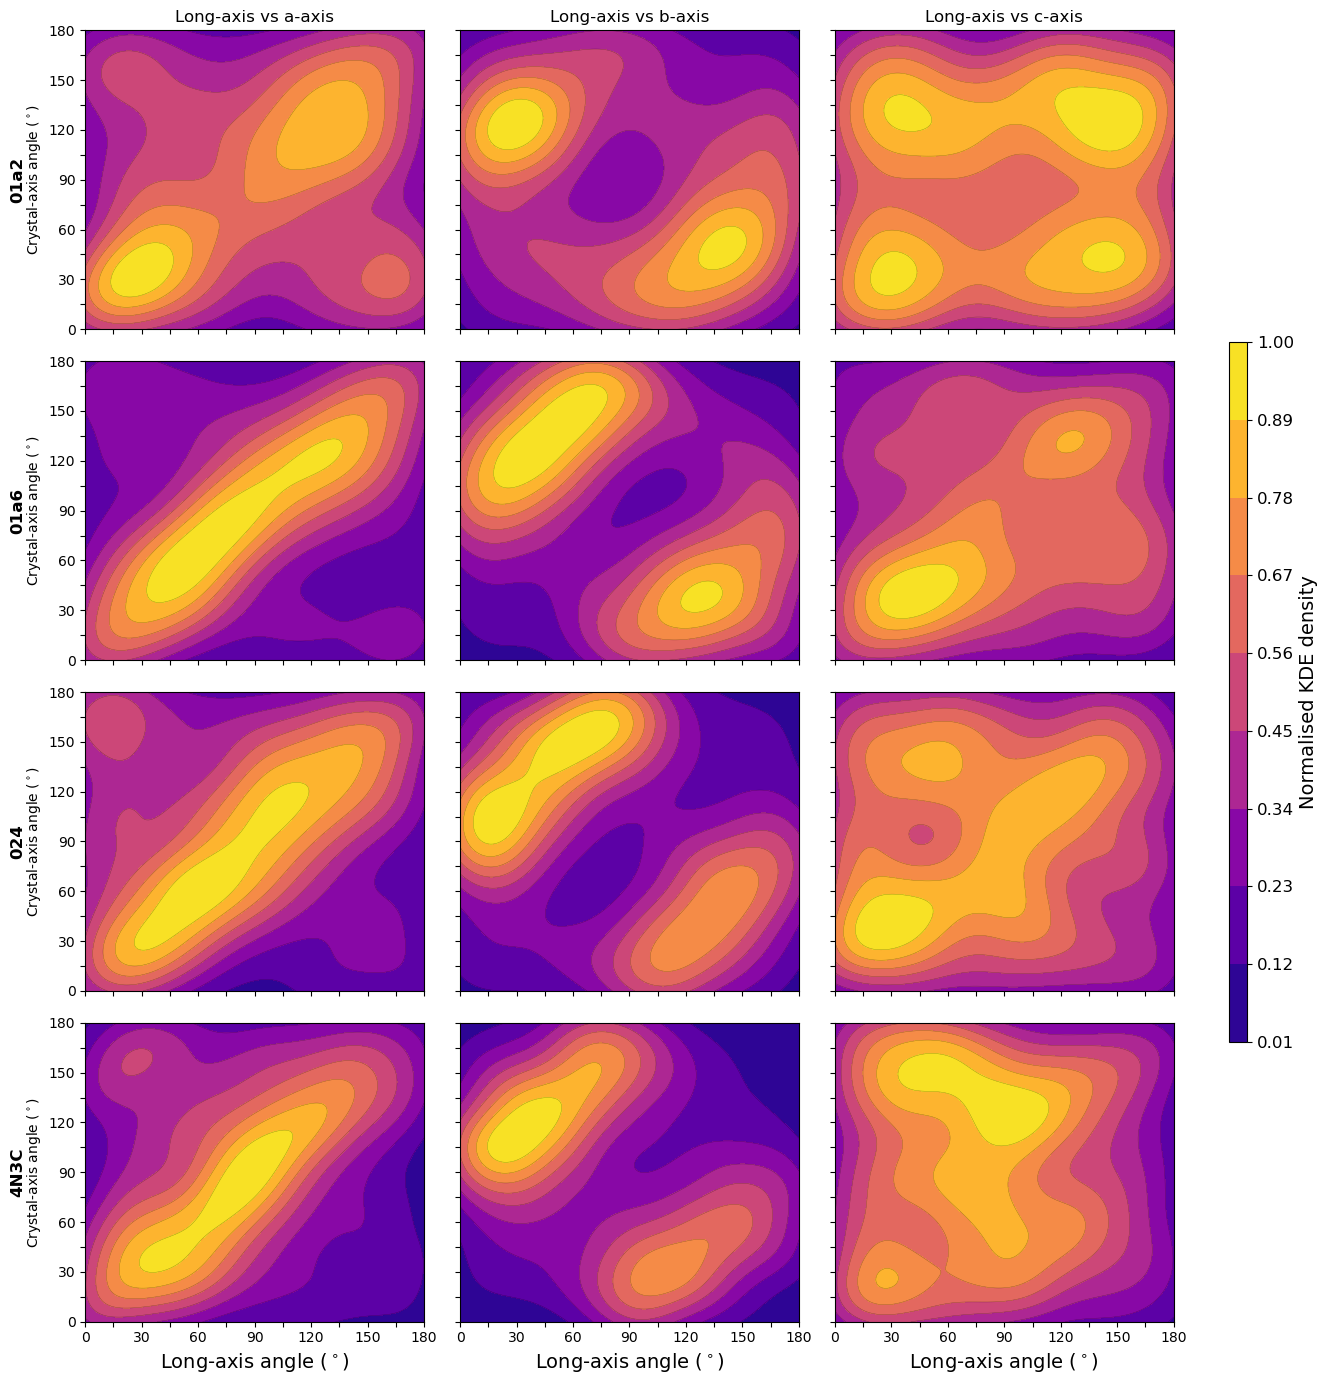

In [8]:
axes_cols = ["aAxisAngle", "bAxisAngle", "cAxisAngle"]
axis_labels = ["a-axis", "b-axis", "c-axis"]

nrows = len(samples)
ncols = 3

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)

if nrows == 1:
    axes = axes.reshape(1, -1)

xmin, xmax = 0, 180
ymin, ymax = 0, 180

xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 200),
    np.linspace(ymin, ymax, 200)
)

levels = np.linspace(0.01, 1, 10)
contour_handle = None

for i, sample in enumerate(samples):
    data_sample = an_grains.loc[an_grains["Sample"].astype(str) == sample]

    for j, (col, label) in enumerate(zip(axes_cols, axis_labels)):
        ax = axes[i, j]
        data = data_sample[["LongAxisAngle", col]].dropna()

        if len(data) < 5:
            ax.set_visible(False)
            continue

        x = data["LongAxisAngle"].to_numpy()
        y = data[col].to_numpy()

        kde = gaussian_kde(np.vstack([x, y]))
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        zz = zz / zz.max()

        ax.scatter(x, y, s=5, color="black", alpha=0.12, linewidths=0)
        cf = ax.contourf(xx, yy, zz, levels=levels, cmap="plasma", extend="neither")
        ax.contour(xx, yy, zz, levels=levels, colors="black", linewidths=0.3, alpha=0.4)
        contour_handle = cf

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        if i == 0:
            ax.set_title(f"Long-axis vs {label}", fontsize=12)

        if j == 0:
            ax.set_ylabel("Crystal-axis angle ($^\\circ$)", fontsize=10)
            ax.text(
                -0.2, 0.5, sample,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=12,
                fontweight="bold"
            )

        if i == nrows - 1:
            ax.set_xlabel("Long-axis angle ($^\\circ$)")

        ax.set_xticks(np.arange(0, 181, 15))
        ax.set_xticklabels([str(int(x)) if x % 30 == 0 else "" for x in np.arange(0, 181, 15)])
        ax.set_yticks(np.arange(0, 181, 15))
        ax.set_yticklabels([str(int(y)) if y % 30 == 0 else "" for y in np.arange(0, 181, 15)])
        ax.tick_params(axis="both", labelsize=10)

fig.subplots_adjust(right=0.9, hspace=0.2, wspace=0.2)

if contour_handle is not None:
    cax = fig.add_axes([1.02, 0.25, 0.015, 0.5])
    cbar = fig.colorbar(contour_handle, cax=cax, format="%.2f")
    cbar.set_label("Normalised KDE density")
    
savefig("LongAxis_vs_CrystalAxes.png")
plt.show()

## Figure 6: Nearest-neighbour SPO--CPO coupling

This figure compares nearest-neighbour long-axis angular differences with nearest-neighbour crystallographic axis-angle differences. Filled contours show normalised kernel density estimates within each sample-axis panel.

C:\Users\d67199rs\AppData\Local\Temp\ipykernel_20460\2870032590.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


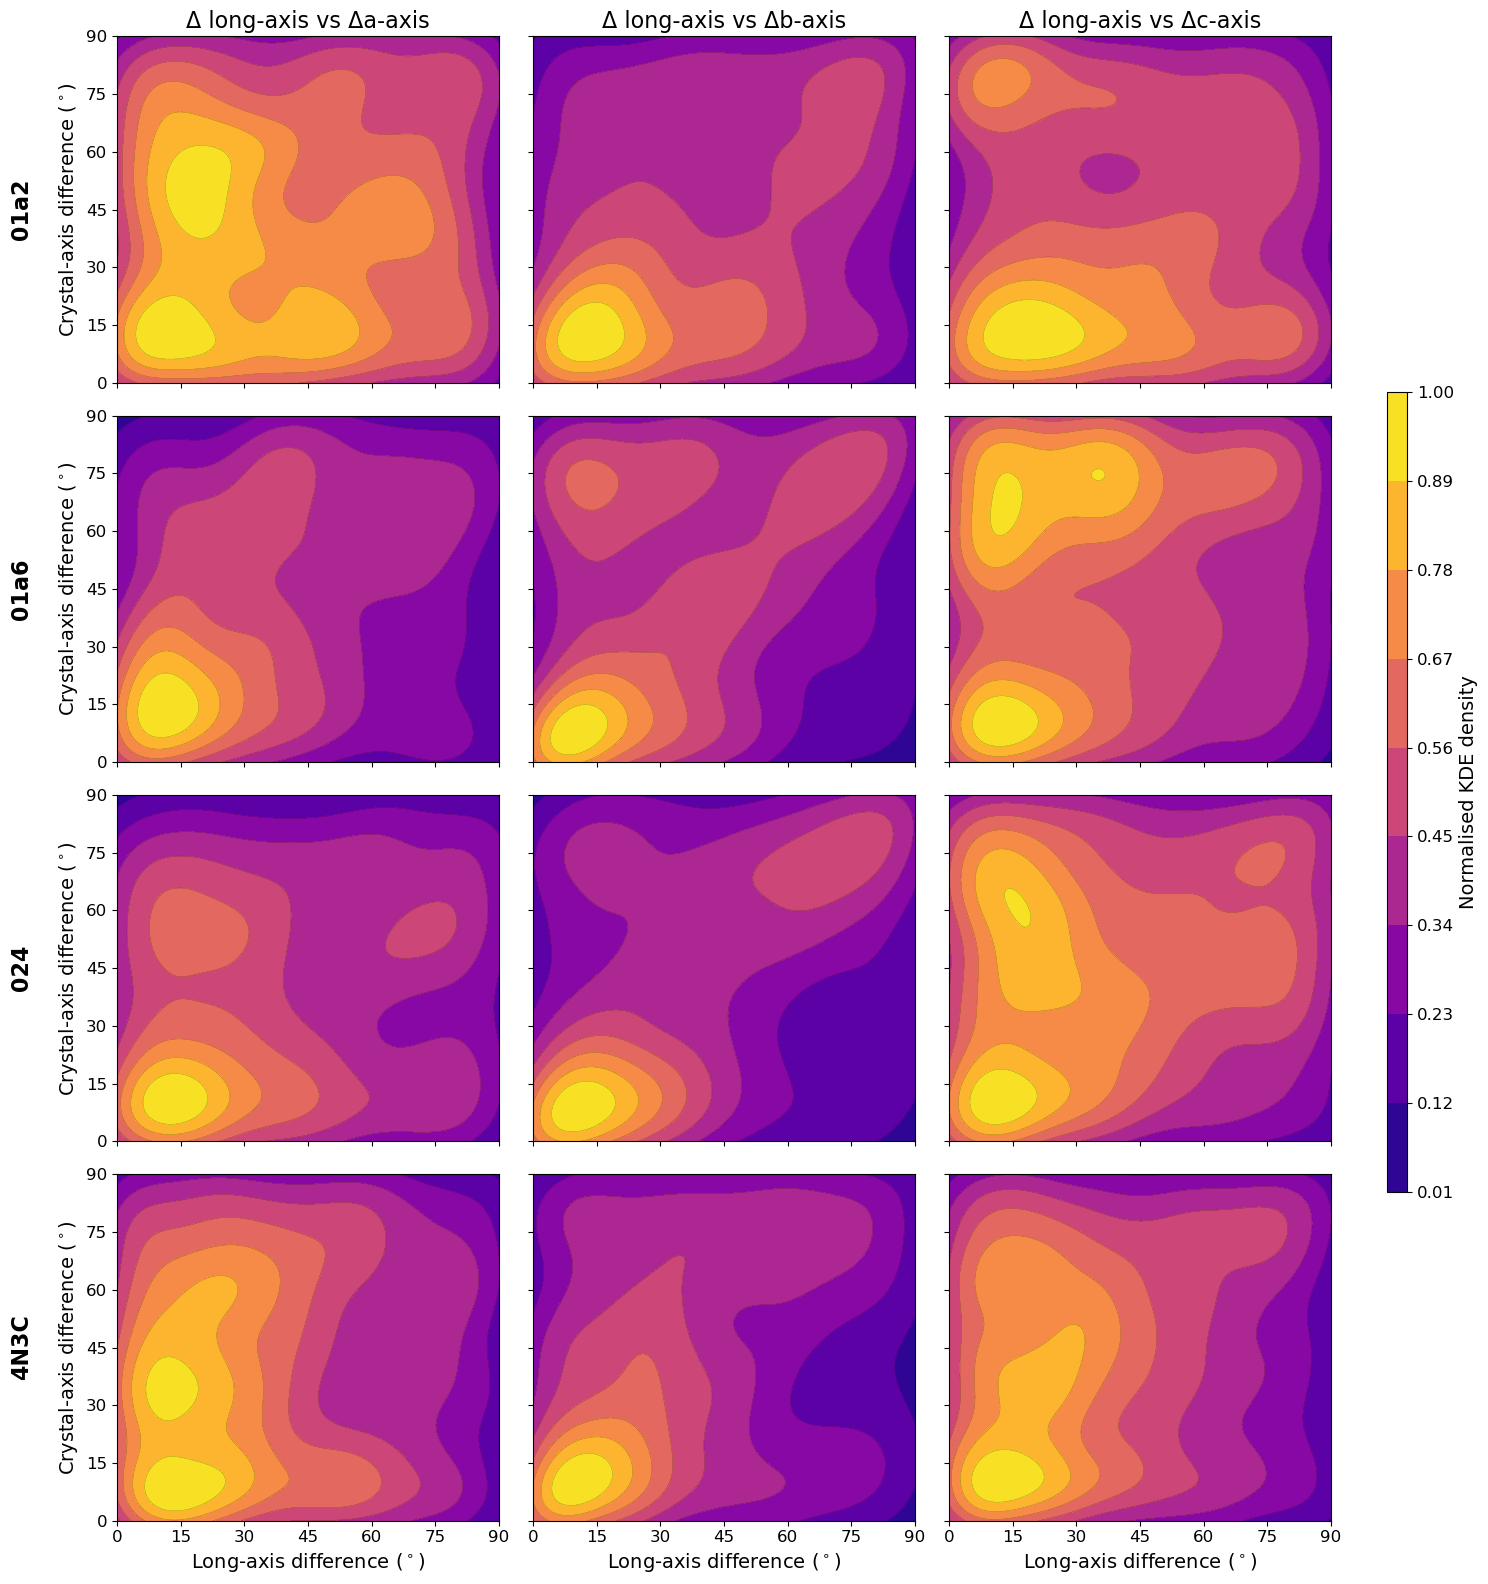

In [10]:
axis_cols = ["DeltaAAxisDeg", "DeltaBAxisDeg", "DeltaCAxisDeg"]
axis_labels = ["Δa-axis", "Δb-axis", "Δc-axis"]

nrows = len(samples)
ncols = 3

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.5 * ncols, 4.0 * nrows),
    sharex=True,
    sharey=True
)

if nrows == 1:
    axes = axes.reshape(1, -1)

xmin, xmax = 0, 90
ymin, ymax = 0, 90

xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 200),
    np.linspace(ymin, ymax, 200)
)

levels = np.linspace(0.01, 1.0, 10)
contour_handle = None

for i, sample in enumerate(samples):
    data_sample = contacts.loc[contacts["Sample"].astype(str) == sample]

    for j, (col, label) in enumerate(zip(axis_cols, axis_labels)):
        ax = axes[i, j]
        data = data_sample[["DeltaLongAxisDeg", col]].dropna()

        if len(data) < 5:
            ax.set_visible(False)
            continue

        x = data["DeltaLongAxisDeg"].to_numpy()
        y = data[col].to_numpy()

        kde = gaussian_kde(np.vstack([x, y]))
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        zz = zz / zz.max()

        ax.scatter(x, y, s=5, color="black", alpha=0.12, linewidths=0)
        cf = ax.contourf(xx, yy, zz, levels=levels, cmap="plasma", extend="neither")
        ax.contour(xx, yy, zz, levels=levels, colors="black", linewidths=0.3, alpha=0.4)
        contour_handle = cf

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks(np.arange(0, 91, 15))
        ax.set_yticks(np.arange(0, 91, 15))

        if i == 0:
            ax.set_title(f"Δ long-axis vs {label}", fontsize=16)

        if j == 0:
            ax.set_ylabel("Crystal-axis difference ($^\\circ$)", fontsize=14)
            ax.text(
                -0.25, 0.5, sample,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=16,
                fontweight="bold"
            )

        if i == nrows - 1:
            ax.set_xlabel("Long-axis difference ($^\\circ$)", fontsize=14)

fig.subplots_adjust(right=0.90, hspace=0.25, wspace=0.18)

if contour_handle is not None:
    cax = fig.add_axes([1.02, 0.25, 0.015, 0.5])
    cbar = fig.colorbar(contour_handle, cax=cax, format="%.2f")
    cbar.set_label("Normalised KDE density")

savefig("DeltaLongAxis_vs_DeltaCrystalAxes.png")
plt.show()

## Optional diagnostics

These summaries are used to check sample sizes and numerical ranges before interpretation.

In [11]:
grain_summary = (
    an_grains
    .groupby("Sample")
    .agg(
        NGrains=("GrainID", "count"),
        ECD_median=("ECD", "median"),
        ECD_IQR=("ECD", lambda x: x.quantile(0.75) - x.quantile(0.25)),
        AR_median=("AspectRatio", "median"),
        AR_IQR=("AspectRatio", lambda x: x.quantile(0.75) - x.quantile(0.25)),
        GOS_median=("GOS", "median"),
        GOS_IQR=("GOS", lambda x: x.quantile(0.75) - x.quantile(0.25))
    )
    .reset_index()
)

display(grain_summary)

if not contacts.empty:
    contact_summary = (
        contacts
        .groupby("Sample")
        .agg(
            NContacts=("GrainID_1", "count"),
            Misorientation_median=("MisorientationDeg", "median"),
            DeltaLongAxis_median=("DeltaLongAxisDeg", "median"),
            DeltaA_median=("DeltaAAxisDeg", "median"),
            DeltaB_median=("DeltaBAxisDeg", "median"),
            DeltaC_median=("DeltaCAxisDeg", "median")
        )
        .reset_index()
    )

    display(contact_summary)

,Sample,NGrains,ECD_median,ECD_IQR,AR_median,AR_IQR,GOS_median,GOS_IQR
0,01a2,479,415.264138,509.989864,1.609511,0.621358,0.776419,1.119221
1,01a6,448,489.311818,584.589312,1.795954,0.829768,0.729179,0.813617
2,024,507,365.964938,414.615249,1.788367,0.765146,0.503394,0.369739
3,4N3C,678,360.541920,363.422027,1.728227,0.696636,0.446645,0.420248


,Sample,NContacts,Misorientation_median,DeltaLongAxis_median,DeltaA_median,DeltaB_median,DeltaC_median
0,01a2,830,139.004542,39.015878,40.248988,36.619368,36.789228
1,01a6,674,131.341304,34.346849,36.396817,43.750152,49.255286
2,024,592,137.345533,35.014090,37.124714,38.623277,43.792651
3,4N3C,973,141.314917,31.390786,38.944225,38.277494,41.440820
